In [1]:
"""I will be working inside of Google Colab
Colab doesnt have LaTeX installed by default, so this installs it
All plots now will render exactly like the ones in the paper
The code below will produce a suppressed run, so itll suppress most of its progress,
while redirecting the normal output to a "null" destination,
while still being allowed to print errors/warnings"""
!apt-get install texlive texlive-latex-extra texlive-fonts-recommended cm-super dvipng -y -qq > /dev/null

Extracting templates from packages: 100%


In [2]:
### To access the date file via github as it doesnt exist in this colab session by default
!git clone https://github.com/German-s04/self-similarity-project.git

Cloning into 'self-similarity-project'...
remote: Enumerating objects: 77, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 77 (delta 27), reused 30 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (77/77), 1015.59 KiB | 16.12 MiB/s, done.
Resolving deltas: 100% (27/27), done.


In [3]:
### Load the necessary libraries

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import minimize
import pickle

plt.rc('text',usetex=True)
plt.rc('font',family='serif',size=14)

In [4]:
### Load data

with open('self-similarity-project/boundary_layer/BL_params.pkl', 'rb') as file:
    data = pickle.load(file)

x = data['x'] # streamwise locations, x/d
y = data['y'] # crosswise locations, y/d
u = data['u'] # mean streamwise velocity [m/s]
U_inf = data['U_inf'] # freestream velocity [m/s]
nu = data['nu'] # viscosity [m^2/s]

/tmp/ipykernel_3480/1769142400.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap('copper', len(x))


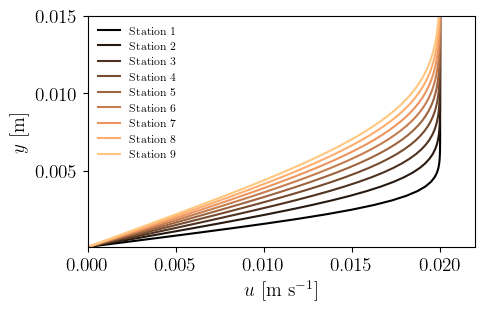

In [5]:
### Plot profiles

color_map = cm.get_cmap('copper', len(x))

plt.figure(1,figsize=(5,3))
for i in range(len(x)):
    color = color_map(i / (len(x) - 1))
    plt.plot(u[i,:], y[i,:], label=f"Station {i + 1}", color=color)

plt.xlabel(r"$u$ [m s$^{-1}$]")
plt.ylabel(r"$y$ [m]")
plt.xlim([0, 1.1*U_inf])
plt.ylim([np.min(y), 0.015])
plt.legend(frameon=False,fontsize=8, loc='upper left')

plt.show()

In [6]:
### Collapse the profiles (equation 2.2)

def loss(var, xin, yin):
    vari  = np.reshape(var,(len(x),2))
    xtran = vari[:,0][:,np.newaxis]*xin
    ytran = vari[:,1][:,np.newaxis]*yin

    # interpolate at the transformed coordinates grid
    ninterp = np.shape(y)[1]
    llim    = np.max(np.amin(xtran,axis=1))
    ulim    = np.min(np.amax(xtran,axis=1))
    newgr   = np.linspace(llim,ulim,ninterp)
    new_y   = np.zeros((len(x),ninterp))
    for i in range(len(x)):
        new_y[i,:] = np.interp(newgr,xtran[i,:],ytran[i,:])

    # compute distances
    dist_mat = np.zeros((len(x),len(x)))
    for i in range(len(x)):
        for j in range(len(x)):
            dist_mat[i,j] = (np.linalg.norm(new_y[i,:] - new_y[j,:]))**2

    dist = np.sum(dist_mat)/2.0

    return dist

# Define parameters and initialise transformation matrices
varopt = np.ones((2*len(x)))

bounds = np.zeros((2*len(x),2))
bounds[:,0] = 0
bounds[:,1] = None

# Optimisation
res = minimize(loss, varopt, args=(y, u), bounds=bounds)

varm = np.reshape(res.x,(len(x),2))
t1   = varm[:,0]
t2   = varm[:,1]

In [16]:
### Collapse the profiles (equation 2.3)

def loss_eq23(var, xin, yin, eps_rel=1e-6):
    vari  = np.reshape(var,(len(x),2))
    xtran = vari[:,0][:,np.newaxis]*xin
    ytran = vari[:,1][:,np.newaxis]*yin

    # interpolate at the transformed coordinates grid
    ninterp = np.shape(y)[1]
    llim    = np.max(np.amin(xtran,axis=1))
    ulim    = np.min(np.amax(xtran,axis=1))
    newgr   = np.linspace(llim,ulim,ninterp)
    new_y   = np.zeros((len(x),ninterp))
    for i in range(len(x)):
        new_y[i,:] = np.interp(newgr,xtran[i,:],ytran[i,:])

    # compute distances (Equation 2.3; mean-regularised)
    eps = eps_rel * np.max(np.abs(new_y))

    dist_mat = np.zeros((len(x),len(x)))
    for i in range(len(x)):
        for j in range(len(x)):
            dist_mat[i,j]=(np.linalg.norm((new_y[i,:]-new_y[j,:])/np.sqrt(0.5*np.abs(new_y[i,:]+new_y[j,:])+eps)))**2

    dist = np.sum(dist_mat)/2.0

    return dist

# Define parameters and initialise transformation matrices
varopt = np.ones((2*len(x)))

bounds = np.zeros((2*len(x),2))
bounds[:,0] = 0
bounds[:,1] = None

# Optimisation
res = minimize(loss_eq23, varopt, args=(y, u), bounds=bounds)

varm = np.reshape(res.x,(len(x),2))
t1_reg   = varm[:,0]
t2_reg   = varm[:,1]
print("Any NaNs in result?", np.isnan(res.fun))
print("Final loss value:", res.fun)

/tmp/ipykernel_3480/1868427901.py:23: RuntimeWarning: invalid value encountered in divide
  dist_mat[i,j]=(np.linalg.norm((new_y[i,:]-new_y[j,:])/np.sqrt(0.5*np.abs(new_y[i,:]+new_y[j,:])+eps)))**2


Any NaNs in result? False
Final loss value: 6.47607778414601e-06


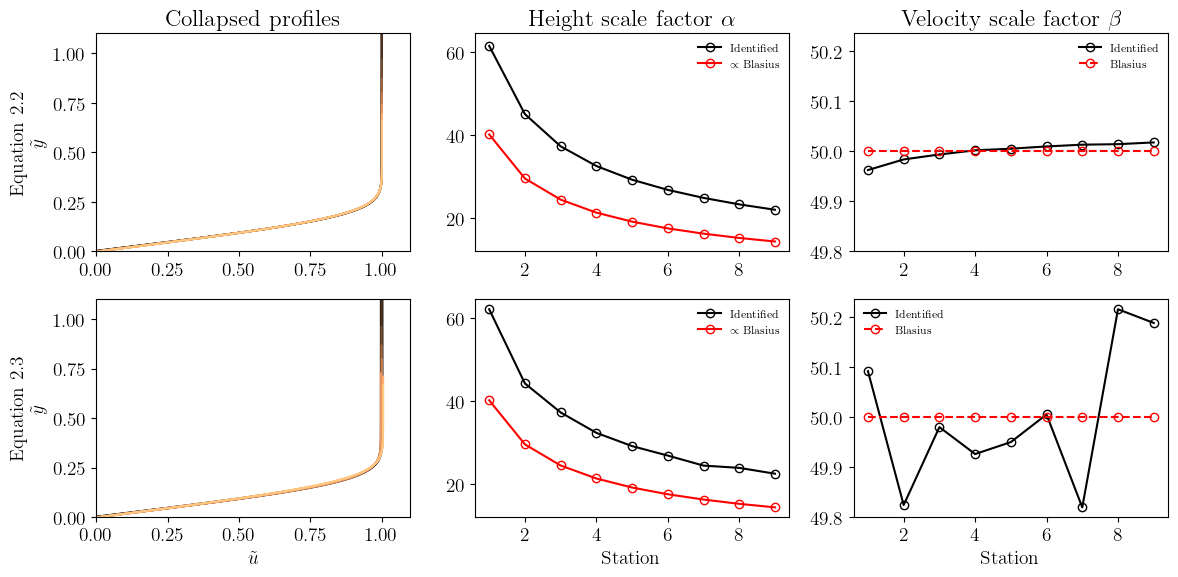

In [17]:
### Compare Equation 2.2 vs Equation 2.3 — side by side

def normalise(field, transform):
    fmin = np.average(np.min(field, axis=1))
    fmax = np.average(np.max(field, axis=1))
    f_norm = (field - fmin) / (fmax - fmin)
    t_norm = (transform - fmin) / (fmax - fmin)
    return f_norm, t_norm

# --- Apply Equation 2.2 scale factors ---
xtran_22 = np.zeros_like(y)
ytran_22 = np.zeros_like(u)
for i in range(len(x)):
    xtran_22[i,:] = y[i,:]*t1[i]
    ytran_22[i,:] = u[i,:]*t2[i]
xtran2_22, t1n_22 = normalise(xtran_22, t1)
ytran2_22, t2n_22 = normalise(ytran_22, t2)

# --- Apply Equation 2.3 scale factors ---
xtran_23 = np.zeros_like(y)
ytran_23 = np.zeros_like(u)
for i in range(len(x)):
    xtran_23[i,:] = y[i,:]*t1_reg[i]
    ytran_23[i,:] = u[i,:]*t2_reg[i]
xtran2_23, t1n_23 = normalise(xtran_23, t1_reg)
ytran2_23, t2n_23 = normalise(ytran_23, t2_reg)

# --- Theoretical comparison curves (same for both rows) ---
scal = np.sqrt(U_inf/(nu*x))

# --- Compute SHARED axis limits across both rows, per column ---
alpha_min = min(np.min(t1n_22), np.min(t1n_23), np.min(scal/8))
alpha_max = max(np.max(t1n_22), np.max(t1n_23), np.max(scal/8))
alpha_pad = 0.05*(alpha_max - alpha_min)

beta_min = min(np.min(t2n_22), np.min(t2n_23), np.min(1/U_inf))
beta_max = max(np.max(t2n_22), np.max(t2n_23), np.max(1/U_inf))
beta_pad = max(0.05*(beta_max - beta_min), 1e-3)  # avoid a zero-width range

# --- Build the figure: 2 rows x 3 columns ---
fig, ax = plt.subplots(2, 3, figsize=(12, 6))

for i in range(len(x)):
    color = color_map(i / (len(x) - 1))
    ax[0,0].plot(ytran2_22[i,:], xtran2_22[i,:], color=color)
    ax[1,0].plot(ytran2_23[i,:], xtran2_23[i,:], color=color)

ax[0,0].set_xlim([0, 1.1]); ax[0,0].set_ylim([0, 1.1])
ax[1,0].set_xlim([0, 1.1]); ax[1,0].set_ylim([0, 1.1])
ax[0,0].set_title("Collapsed profiles")
ax[0,0].set_ylabel("Equation 2.2\n" + r"$\tilde{y}$")
ax[1,0].set_ylabel("Equation 2.3\n" + r"$\tilde{y}$")
ax[1,0].set_xlabel(r"$\tilde{u}$")

# Middle column: height-scale factor vs theory — SHARED y-limits
ax[0,1].plot(np.arange(len(x))+1, t1n_22, '-ko', mfc='none', label='Identified')
ax[0,1].plot(np.arange(len(x))+1, scal/8, '-ro', mfc='none', label=r'$\propto$ Blasius')
ax[1,1].plot(np.arange(len(x))+1, t1n_23, '-ko', mfc='none', label='Identified')
ax[1,1].plot(np.arange(len(x))+1, scal/8, '-ro', mfc='none', label=r'$\propto$ Blasius')
ax[0,1].set_ylim([alpha_min - alpha_pad, alpha_max + alpha_pad])
ax[1,1].set_ylim([alpha_min - alpha_pad, alpha_max + alpha_pad])
ax[0,1].set_title(r"Height scale factor $\alpha$")
ax[1,1].set_xlabel("Station")
ax[0,1].legend(frameon=False, fontsize=8)
ax[1,1].legend(frameon=False, fontsize=8)

# Right column: velocity-scale factor vs theory — SHARED y-limits, no offset notation
ax[0,2].plot(np.arange(len(x))+1, t2n_22, '-ko', mfc='none', label='Identified')
ax[0,2].plot(np.arange(len(x))+1, np.tile(1/U_inf, len(x)), '--ro', mfc='none', label='Blasius')
ax[1,2].plot(np.arange(len(x))+1, t2n_23, '-ko', mfc='none', label='Identified')
ax[1,2].plot(np.arange(len(x))+1, np.tile(1/U_inf, len(x)), '--ro', mfc='none', label='Blasius')
ax[0,2].set_ylim([beta_min - beta_pad, beta_max + beta_pad])
ax[1,2].set_ylim([beta_min - beta_pad, beta_max + beta_pad])
ax[0,2].ticklabel_format(useOffset=False, style='plain')
ax[1,2].ticklabel_format(useOffset=False, style='plain')
ax[0,2].set_title(r"Velocity scale factor $\beta$")
ax[1,2].set_xlabel("Station")
ax[0,2].legend(frameon=False, fontsize=8)
ax[1,2].legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

<>:33: SyntaxWarning: invalid escape sequence '\p'
<>:33: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_3480/2381532823.py:33: SyntaxWarning: invalid escape sequence '\p'
  ax[1].plot(np.arange(len(x))+1,scal/8,'-ro',mfc='none', label='$\propto$ Blasius')


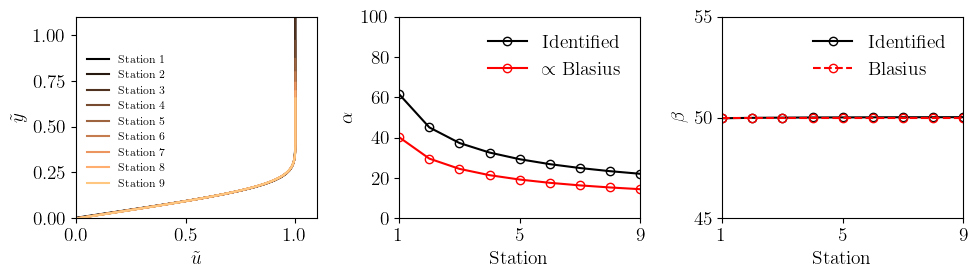

In [9]:
### Normalise and plot data

def normalise(field,transform):
    fmin = np.average(np.min(field,axis=1))
    fmax = np.average(np.max(field,axis=1))
    f_norm = (field-fmin)/(fmax-fmin)
    t_norm = (transform-fmin)/(fmax-fmin)

    return f_norm, t_norm

xtran = np.zeros_like(y)
ytran = np.zeros_like(u)
for i in range(len(x)):
    xtran[i,:]=y[i,:]*t1[i]
    ytran[i,:]=u[i,:]*t2[i]
xtran2, t1n = normalise(xtran,t1)
ytran2, t2n = normalise(ytran,t2)

# Plot data
fig, ax = plt.subplots(1,3,figsize=(10,3))

for i in range(len(x)):
    color = color_map(i / (len(x) - 1))
    ax[0].plot(ytran2[i,:],xtran2[i,:], label=f'Station {i + 1}', color=color)
ax[0].legend(frameon=False, fontsize=8, bbox_to_anchor=(0.41, 0.86))
ax[0].set_xlabel(r'$\tilde{u}$')
ax[0].set_ylabel(r'$\tilde{y}$')
ax[0].set_xlim([0.0,1.1])
ax[0].set_ylim([0.0,1.1])

scal = np.sqrt(U_inf/(nu*x))
ax[1].plot(np.arange(len(x))+1,t1n,'-ko',mfc='none', label='Identified')
ax[1].plot(np.arange(len(x))+1,scal/8,'-ro',mfc='none', label='$\propto$ Blasius')
ax[1].set_xlabel(r'Station')
ax[1].set_ylabel(r'$\alpha$')
ax[1].set_xlim([1,9])
ax[1].set_ylim([0.0,100])
ax[1].set_xticks([1,5,9])
ax[1].legend(frameon=False)

ax[2].plot(np.arange(len(x))+1,t2n,'-ko',mfc='none', label='Identified')
ax[2].plot(np.arange(len(x))+1,np.tile(1/U_inf,len(x)),'--ro',mfc='none', label='Blasius')
ax[2].set_xlabel(r'Station')
ax[2].set_ylabel(r'$\beta$')
ax[2].set_xlim([1,9])
ax[2].set_ylim([45,55])
ax[2].set_xticks([1,5,9])
ax[2].set_yticks([45,50,55])
ax[2].legend(frameon=False)

plt.tight_layout()
plt.show()

In [10]:
### Interpret transformations

# Loss function
def loss(var, target, target_dims, A, A_dims, w1):
    f = np.ones((np.size(target)))
    for i in range(np.shape(A)[1]):
        temp = np.power(A[:,i],var[i+1])
        f   = np.multiply(f,temp)
    f = var[0]*f
    f = np.reshape(f,(np.size(f),1))

    f_dims = np.matmul(A_dims,var[1:])
    f_dims = np.reshape(f_dims,(np.size(f_dims),1))

    dist = np.sum((f - target)**2) + w1*np.sum(np.abs(f_dims - target_dims))

    return dist

# Interpret first identified transformation (alpha)
Xsr1   = np.array([np.tile(U_inf,len(x)), np.tile(nu,len(x)), x]).T
X_dims = np.array([[1,2,1],[0,0,0],[-1,-1,0]]) ## L, M, T

Ysr1 = 1/t1n.copy()
Ysr1 = np.reshape(Ysr1,(np.size(Ysr1),1))
Y_dims = np.array([[1],[0],[0]]) ## L, M, T

weight_dims = 1e-4

# Run optimisation
niter = 30
fmin  = 1e20
for i in range(niter):
    var = np.ones((np.shape(Xsr1)[1]+1,1)) # adding a multiplitative constant to the power law
    var = var.flatten()*np.random.rand(np.size(var))

    res = minimize(loss, var, args=(Ysr1, Y_dims, Xsr1, X_dims, weight_dims))
    if (res.fun < fmin):
        fmin   = res.fun
        var_b1 = res.x

print("The found constant and powers are:", var_b1)
f = np.ones((np.size(Ysr1)))
for i in range(np.shape(Xsr1)[1]):
    temp = np.power(Xsr1[:,i],var_b1[i+1])
    f    = np.multiply(f,temp)
f = var_b1[0]*f
f = np.reshape(f,(np.size(f),1))

f_dims = np.matmul(X_dims,var_b1[1:])
print("The dimensions of the found expression are:", f_dims)

# Interpret second identified transformation (beta)
Xsr2   = np.array([np.tile(U_inf,len(x)), np.tile(nu,len(x)), x]).T
X_dims = np.array([[1,2,1],[0,0,0],[-1,-1,0]]) ## L, M, T

Ysr2   = 1/t2n.copy()
Ysr2   = np.reshape(Ysr2,(np.size(Ysr2),1))
Y_dims = np.array([[1],[0],[-1]]) ## L, M, T

weight_dims = 1e-4

# Run optimisation
niter = 30
fmin  = 1e20
for i in range(niter):
    var = np.ones((np.shape(Xsr2)[1]+1,1)) # adding a multiplitative constant to the power law
    var = var.flatten()*np.random.rand(np.size(var))

    res = minimize(loss, var, args=(Ysr2, Y_dims, Xsr2, X_dims, weight_dims))
    if (res.fun < fmin):
        fmin   = res.fun
        var_b2 = res.x

print("The found constant and powers are:", var_b2)
f = np.ones((np.size(Ysr2)))
for i in range(np.shape(Xsr2)[1]):
    temp = np.power(Xsr2[:,i],var_b2[i+1])
    f    = np.multiply(f,temp)
f = var_b2[0]*f
f = np.reshape(f,(np.size(f),1))

f_dims = np.matmul(X_dims,var_b2[1:])
print("The dimensions of the found expression are:", f_dims)

The found constant and powers are: [ 5.26316301 -0.50117361  0.5011736   0.49882638]
The dimensions of the found expression are: [9.99999974e-01 0.00000000e+00 7.09649473e-09]
The found constant and powers are: [ 1.00208146e+00  9.99499212e-01  5.00464177e-04 -5.00141099e-04]
The dimensions of the found expression are: [ 1.          0.         -0.99999968]


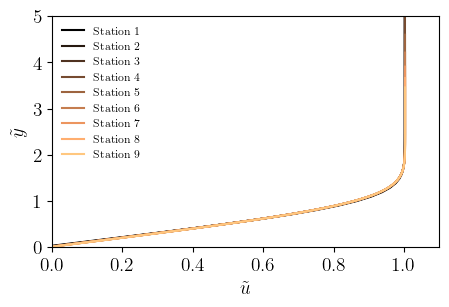

In [11]:
### Plot interpreted collapse

scaly_new = U_inf**var_b1[1] * nu**var_b1[2] * x**var_b1[3]
scalu_new = U_inf**var_b2[1] * nu**var_b2[2] * x**var_b2[3]

y_new = np.zeros((len(x),np.shape(y)[1]))
u_new = np.zeros((len(x),np.shape(y)[1]))
for i in range(np.size(x)):
    y_new[i,:] = y[i,:]/scaly_new[i]
    u_new[i,:] = u[i,:]/scalu_new[i]

plt.figure(1,figsize=(5,3))
for i in range(len(x)):
    color = color_map(i / (len(x) - 1))
    plt.plot(u_new[i,:], y_new[i,:], label=f"Station {i + 1}", color=color)

plt.xlim([0, 1.1])
plt.ylim([0, 5])
plt.legend(frameon=False,fontsize=8, loc='upper left')

plt.xlabel(r'$\tilde{u}$')
plt.ylabel(r'$\tilde{y}$')
plt.show()